In [117]:
words = open("names.txt", "r").read().splitlines()

len(words)

32033

## Bigrams Model using NN

In [118]:
import torch

In [119]:
# We need to get all the unique character in the dataset of number which is simply all 26 character of the alphabet 
a = set(''.join(words)) # gets all the unique characters from the huge string 
chars = sorted(list(set(''.join(words)))) # we want it as a sorted list 
chars

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [120]:
# Because computers only understand numbers, we need to map each character to a number 
# So we need a look up table for 
# stoi - string to interger
# itos = integer to string 

stoi = {s:i+1 for i, s in enumerate(chars)}
stoi["."] = 0
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [121]:
# integer to string 
# get the reverse of stoi 
itos = {i: s for s, i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [122]:
# create training set of all the bigrams 

xs, ys = [], [] # training set: inputs and labels 

for w in words[:1]:
    chs = ["."] + list(w) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1] # map ch1 to its integer value 
        ix2 = stoi[ch2] # map ch2 to its integer value 
        print(ch1, ch2)
        print(ix1, ix2)
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
        

. e
0 5
e m
5 13
m m
13 13
m a
13 1
a .
1 0


In [123]:
xs 

tensor([ 0,  5, 13, 13,  1])

In [124]:
ys

tensor([ 5, 13, 13,  1,  0])

In [125]:
# above, xs is the input dataset, and ys is the target dataset 
# when xs = 0 (char at index 0), we want our NN to predict 5 (assign high probability to the char at index 5)
# when xs = 5 (char at index 5), we want out NN to predict 13 (assign high probability to char at index 13)
# and so on ... 

# xs - input data 
# ys - target output 

# xs and ys is our simple dataset and we are going to create a simple neural network which will be trained on the xs and ys dataset 

In [126]:
# the simple mathematics of a neural net is that we multiply a weight by the input x plus a bias b
# wx + b 

# From the xs input data, out input values are integer values and we know that we cannot use integer values as an input into the NN 
# Also feeding the input values as numbers with magnitude will lead the NN to treat these numbers like there is a numerical relationship
# This false numerical relationship will mislead the NN and thats not what we want 
# 
# To resolve this, we encode the inputs using vectors 
# Each input is represented as a vector of all zeros except a single 1 at the character's index 
# 'a' (index 1) → [0, 1, 0, 0, 0, ...]
# 'b' (index 2) → [0, 0, 1, 0, 0, ...]
# 'c' (index 3) → [0, 0, 0, 1, 0, ...]

# By encoding the inputs as vectors, every character is equidistant from every other character 
# no character is numerically larger, smaller, or closer to another

import torch.nn.functional as F 
xenc = F.one_hot(xs, num_classes=27).float()
xenc # This gives us five rows with 27 columns 
# each row is a seperate input encoded with the index value position set to 1 

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [127]:
xenc.shape

torch.Size([5, 27])

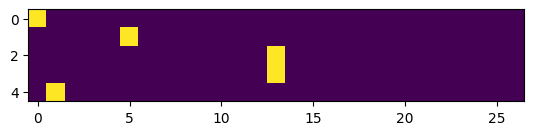

In [128]:
import matplotlib.pyplot as plt
plt.imshow(xenc)

In [129]:
# One problem you should always watch out for is the dtype of your inputs into a NN 
# The datatype should always be floats which can take on a range of values 

xenc.dtype # was initially int dtype until we casted it above 

# so solve this, we cast xenc to float when we encode above 

torch.float32

In [130]:
# create random weights 
W = torch.randn((27, 1))
W

tensor([[-2.1426],
        [ 1.0469],
        [-1.9525],
        [-0.9931],
        [-1.2203],
        [-0.9803],
        [ 1.1387],
        [ 0.3306],
        [-0.9936],
        [-0.1886],
        [ 1.2833],
        [ 0.8044],
        [ 0.0909],
        [ 0.1424],
        [-0.8024],
        [-0.4550],
        [-2.4468],
        [-0.4000],
        [ 0.3558],
        [-0.5446],
        [-0.5541],
        [-0.5458],
        [-0.4005],
        [ 0.7641],
        [-0.5947],
        [-1.2659],
        [ 2.4801]])